In [1]:
import pandas as pd

In [2]:
accepted_df = pd.read_csv('../../data/lendingclub/raw/accepted_2007_to_2018Q4.csv')
rejected_df = pd.read_csv('../../data/lendingclub/raw/rejected_2007_to_2018Q4.csv')

C:\Users\DILSHOD\AppData\Local\Temp\ipykernel_18112\2435792480.py:1: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  accepted_df = pd.read_csv('../../data/lendingclub/raw/accepted_2007_to_2018Q4.csv')


In [3]:
accepted_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(1), str(37)
memory usage: 2.5+ GB


In [4]:
rejected_df.head()

,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,481xx,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,010xx,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,212xx,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,017xx,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,209xx,MD,< 1 year,0.0


In [5]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

df = pd.read_csv(ROOT / "data/lendingclub/processed/application_train.csv", low_memory=False)

print(df.shape)
print(df["TARGET"].mean())
print(df["loan_status"].value_counts(dropna=False))

suspect = [
    "loan_status",
    "title",
    "policy_code",
    "pymnt_plan",
    "disbursement_method",
    "debt_settlement_flag",
    "debt_settlement_flag_date",
    "deferral_term",
    "payment_plan_start_date",
    "orig_projected_additional_accrued_interest",
]
print(df[suspect].isna().mean().sort_values(ascending=False))

missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(25))

card = df.select_dtypes(include=["object"]).nunique(dropna=True).sort_values(ascending=False)
print(card.head(25))

monthly = (
    df.assign(issue_d=pd.to_datetime(df["issue_d"], errors="coerce"))
      .groupby(pd.Grouper(key="issue_d", freq="MS"))
      .agg(n=("TARGET", "size"), bad_rate=("TARGET", "mean"))
)
print(monthly.tail(24))

(1373915, 109)
0.21484298519195147
loan_status
Fully Paid                                             1076751
Charged Off                                             268559
Late (31-120 days)                                       21467
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64
orig_projected_additional_accrued_interest    0.996033
deferral_term                                 0.994446
payment_plan_start_date                       0.994446
debt_settlement_flag_date                     0.975102
title                                         0.012380
loan_status                                   0.000000
debt_settlement_flag                          0.000000
disbursement_method                           0.000000
pymnt_plan                                    

C:\Users\DILSHOD\AppData\Local\Temp\ipykernel_18112\3284997033.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  card = df.select_dtypes(include=["object"]).nunique(dropna=True).sort_values(ascending=False)


title                        63153
earliest_cr_line               739
sec_app_earliest_cr_line       583
issue_d                        139
debt_settlement_flag_date       83
addr_state                      51
payment_plan_start_date         27
purpose                         14
emp_length                      11
loan_status                      7
home_ownership                   6
verification_status_joint        3
verification_status              3
term                             2
pymnt_plan                       2
initial_list_status              2
application_type                 2
disbursement_method              2
debt_settlement_flag             2
dtype: int64
                n  bad_rate
issue_d                    
2017-01-01  16955  0.252433
2017-02-01  13989  0.260776
2017-03-01  17664  0.257982
2017-04-01  13672  0.269675
2017-05-01  16888  0.272560
2017-06-01  16040  0.274875
2017-07-01  15813  0.281730
2017-08-01  16467  0.274792
2017-09-01  14402  0.301764
2017-10-01  12

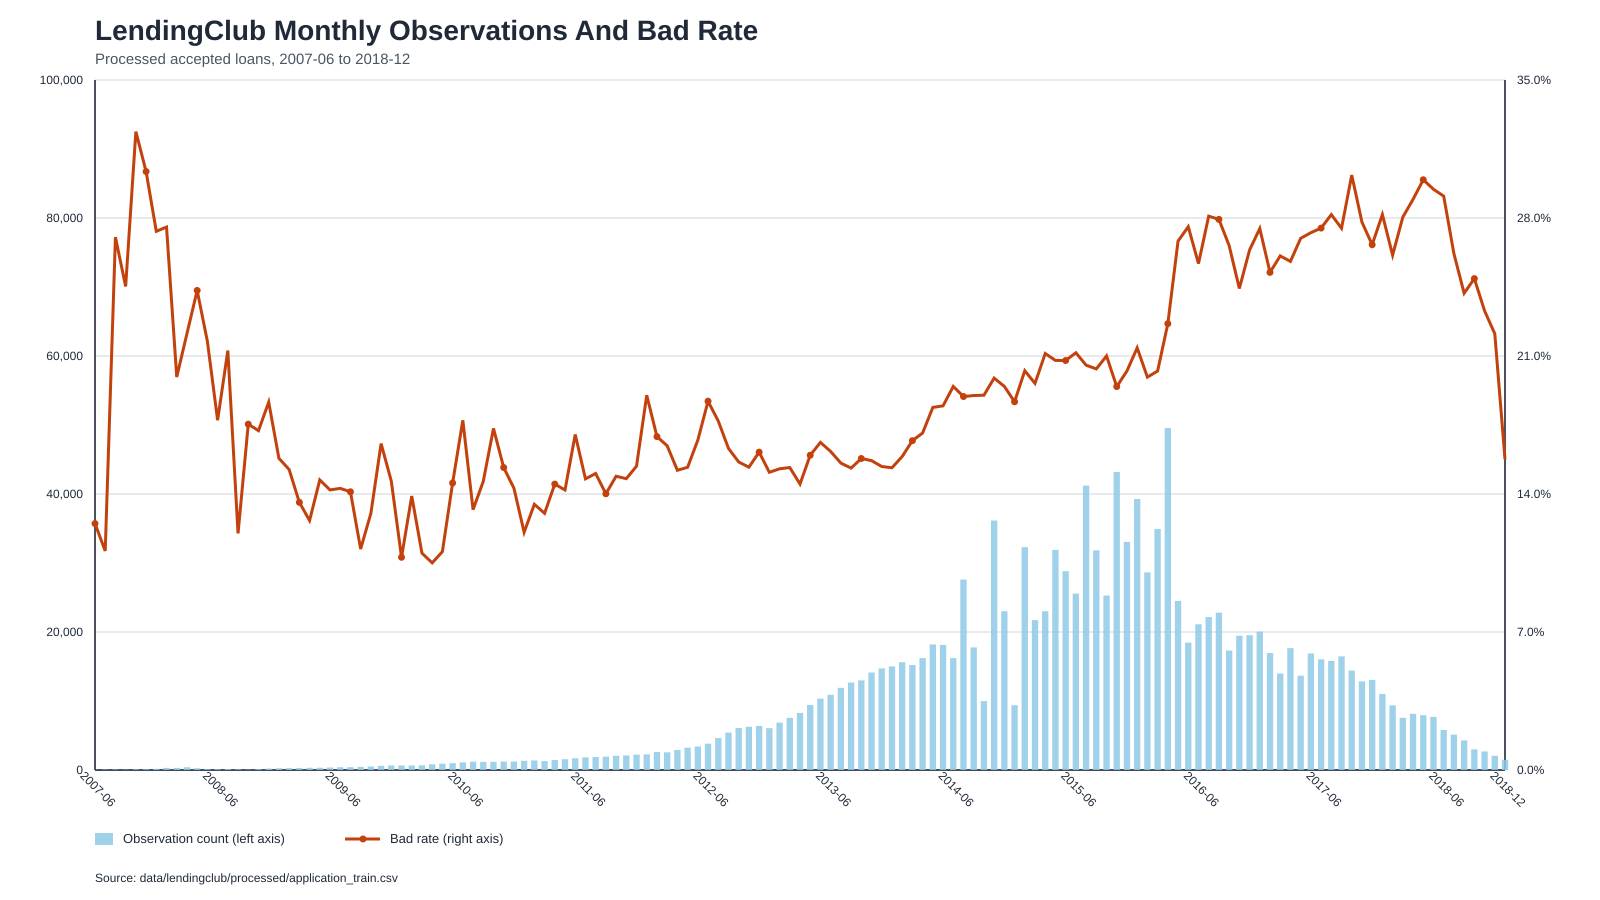

In [6]:
from IPython.display import SVG, display
display(SVG(filename="../../reports/lendingclub_monthly_bad_rate_observation_count.svg"))

### application_train

In [7]:
df = pd.read_csv('../../data/lendingclub/processed/application_train.csv')

C:\Users\DILSHOD\AppData\Local\Temp\ipykernel_18112\2879868363.py:1: DtypeWarning: Columns (0: verification_status_joint, 1: sec_app_earliest_cr_line, 2: payment_plan_start_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/lendingclub/processed/application_train.csv')


In [9]:
import pandas as pd

# Assumes df already exists and contains:
# - TARGET
# - recent_decision
# - issue_d

DEV_START = -1795   # 2014-01-01
OOT_START = -1065   # 2016-01-01
OOT_END = -730      # 2016-12-01

df["issue_d"] = pd.to_datetime(df["issue_d"], errors="coerce")

dev_df = df[
    (df["recent_decision"] >= DEV_START)
    & (df["recent_decision"] < OOT_START)
].copy()

oot_df = df[
    (df["recent_decision"] >= OOT_START)
    & (df["recent_decision"] <= OOT_END)
].copy()

print("DEV shape:", dev_df.shape)
print("OOT shape:", oot_df.shape)

print("\nDEV bad rate:", dev_df["TARGET"].mean())
print("OOT bad rate:", oot_df["TARGET"].mean())

print("\nDEV date range:", dev_df["issue_d"].min(), "to", dev_df["issue_d"].max())
print("OOT date range:", oot_df["issue_d"].min())

DEV shape: (600694, 109)
OOT shape: (298553, 109)

DEV bad rate: 0.19812250496925224
OOT bad rate: 0.24685734191249126

DEV date range: 2014-01-01 00:00:00 to 2015-12-01 00:00:00
OOT date range: 2016-01-01 00:00:00


In [12]:
df.columns.tolist()

['loan_amnt',
 'term',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'title',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
